# Experiment 9

In [ ]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2

# save to Google Drive
from google.colab import drive
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/MSDS458_RA02_Experiments"
os.makedirs(base_dir, exist_ok=True)
print("Saving to:", base_dir)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving to: /content/drive/MyDrive/MSDS458_RA02_Experiments


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(
    x_train, y_train, test_size=0.10, random_state=SEED, shuffle=True
)

x_train_norm = x_train_split.astype("float32") / 255.0
x_valid_norm = x_valid_split.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

print("Train:", x_train_norm.shape, y_train_split.shape)
print("Valid:", x_valid_norm.shape, y_valid_split.shape)
print("Test :", x_test_norm.shape,  y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (45000, 32, 32, 3) (45000, 1)
Valid: (5000, 32, 32, 3) (5000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


In [ ]:
def compile_train_model(model, exp_name,
                        x_train, y_train,
                        x_valid, y_valid,
                        optimizer='adam',
                        batch_size=64,
                        epochs=200,
                        patience=3,
                        save_dir=base_dir):

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    ckpt_path = os.path.join(save_dir, f"{exp_name}.keras")

    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=True, save_weights_only=False),
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True)
    ]

    t0 = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    train_time = round(time.time() - t0, 2)
    print(f"Finished {exp_name} in {train_time}s")
    return history, train_time, ckpt_path


In [ ]:
def plot_history(history, title=""):
    df = pd.DataFrame(history.history)
    plt.figure(figsize=(16,5))

    plt.subplot(1,2,1)
    plt.plot(df["accuracy"]); plt.plot(df["val_accuracy"])
    plt.title(f"Accuracy {title}")
    plt.xlabel("epoch"); plt.ylabel("accuracy")
    plt.legend(["train","val"])

    plt.subplot(1,2,2)
    plt.plot(df["loss"]); plt.plot(df["val_loss"])
    plt.title(f"Loss {title}")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend(["train","val"])

    plt.show()
    return df

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    mtx = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12,9))
    sns.heatmap(mtx, annot=False, cmap="Blues", fmt="d")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(title)
    plt.show()


In [ ]:
results_df = pd.DataFrame(columns=[
    "experiment","params",
    "train_loss","train_acc",
    "val_loss","val_acc",
    "test_loss","test_acc",
    "train_time_sec","optimizer","batch_size","epochs_ran"
])
results_df


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran


In [ ]:
K.clear_session()
exp_name9 = "Exp9_CNN_2block_L2_dropout"

L2_LAMBDA = 1e-4
DROPOUT_RATE = 0.25

cnn2_reg = Sequential([
    Input(shape=(32,32,3)),

    Conv2D(32, (3,3), activation="relu", padding="same",
           kernel_regularizer=l2(L2_LAMBDA)),
    MaxPooling2D((2,2)),
    Dropout(DROPOUT_RATE),

    Conv2D(64, (3,3), activation="relu", padding="same",
           kernel_regularizer=l2(L2_LAMBDA)),
    MaxPooling2D((2,2)),
    Dropout(DROPOUT_RATE),

    Flatten(),
    Dense(128, activation="relu", kernel_regularizer=l2(L2_LAMBDA)),
    Dropout(DROPOUT_RATE),
    Dense(10, activation="softmax")
], name=exp_name9)

cnn2_reg.summary()


Model: "Exp9_CNN_2block_L2_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 139ms/step - accuracy: 0.2959 - loss: 1.9274 - val_accuracy: 0.5436 - val_loss: 1.3351
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 130s 185ms/step - accuracy: 0.5134 - loss: 1.3897 - val_accuracy: 0.5980 - val_loss: 1.1595
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.5644 - loss: 1.2531 - val_accuracy: 0.6354 - val_loss: 1.0818
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 130ms/step - accuracy: 0.5978 - loss: 1.1788 - val_accuracy: 0.6604 - val_loss: 1.0285
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 123ms/step - accuracy: 0.6218 - loss: 1.1306 - val_accuracy: 0.6756 - val_loss: 1.0012
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.6416 - loss: 1.0857 - val_accuracy: 0.6766 - val_loss: 0.9820
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.6526 - loss: 1.0607 - val_accuracy: 0.6930 - val_loss: 0.9636
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.66

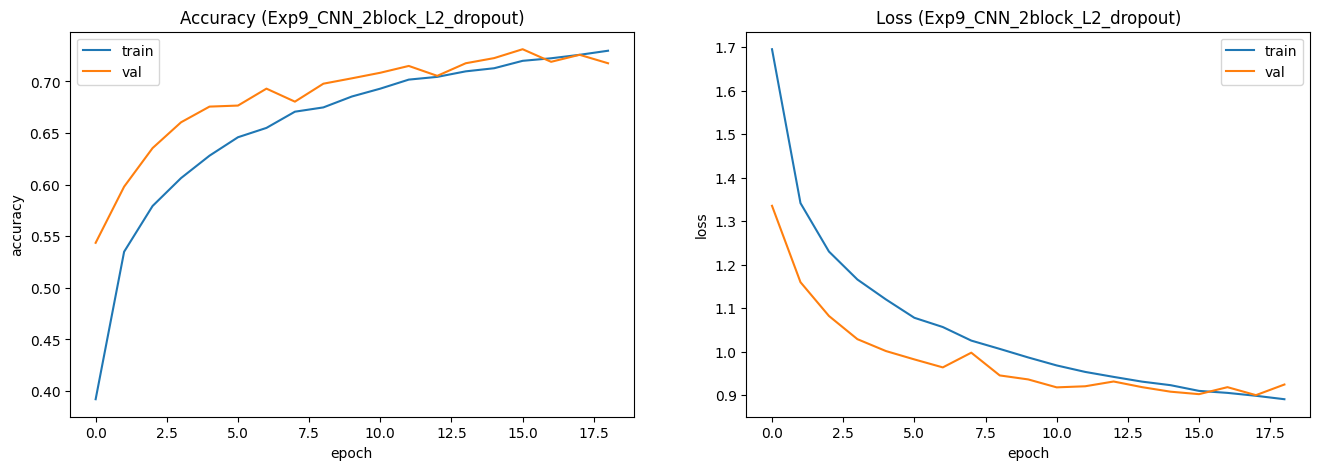

Saved model: /content/drive/MyDrive/MSDS458_RA02_Experiments/Exp9_CNN_2block_L2_dropout.keras


In [ ]:
history9, time9, path9 = compile_train_model(
    cnn2_reg, exp_name9,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    optimizer="adam",
    batch_size=64,
    epochs=200,
    patience=3,
    save_dir=base_dir
)

history_df9 = plot_history(history9, title=f"({exp_name9})")
print("Saved model:", path9)


Train acc: 0.8270 | loss: 0.6629
Val   acc: 0.7258 | loss: 0.8998
Test  acc: 0.7241 | loss: 0.9207

Classification Report (Exp9)
              precision    recall  f1-score   support

           0      0.732     0.806     0.767      1000
           1      0.819     0.839     0.829      1000
           2      0.637     0.563     0.598      1000
           3      0.531     0.522     0.526      1000
           4      0.724     0.651     0.686      1000
           5      0.616     0.622     0.619      1000
           6      0.752     0.811     0.781      1000
           7      0.803     0.766     0.784      1000
           8      0.813     0.841     0.827      1000
           9      0.793     0.820     0.806      1000

    accuracy                          0.724     10000
   macro avg      0.722     0.724     0.722     10000
weighted avg      0.722     0.724     0.722     10000

Accuracy Score: 0.7241


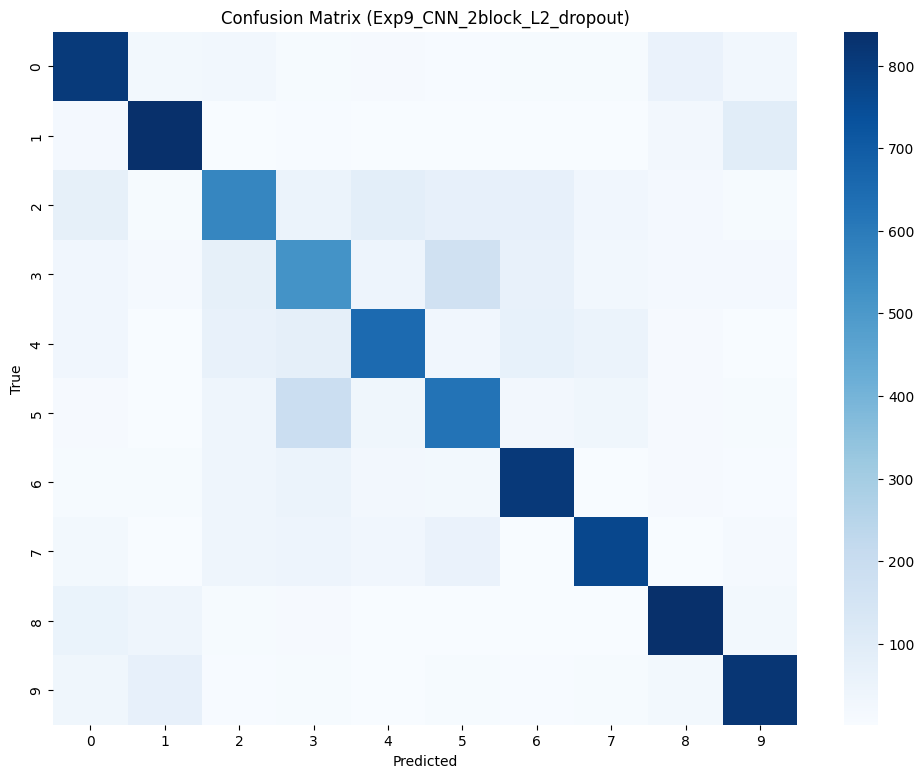

In [ ]:
best9 = load_model(path9)

train_loss9, train_acc9 = best9.evaluate(x_train_norm, y_train_split, verbose=0)
val_loss9, val_acc9     = best9.evaluate(x_valid_norm, y_valid_split, verbose=0)
test_loss9, test_acc9   = best9.evaluate(x_test_norm,  y_test,        verbose=0)

print(f"Train acc: {train_acc9:.4f} | loss: {train_loss9:.4f}")
print(f"Val   acc: {val_acc9:.4f} | loss: {val_loss9:.4f}")
print(f"Test  acc: {test_acc9:.4f} | loss: {test_loss9:.4f}")

y_prob9 = best9.predict(x_test_norm, verbose=0)
y_pred9 = np.argmax(y_prob9, axis=1)
y_true9 = y_test.reshape(-1)

print("\nClassification Report (Exp9)")
print(classification_report(y_true9, y_pred9, digits=3))
print("Accuracy Score:", accuracy_score(y_true9, y_pred9))

plot_confusion_matrix(y_true9, y_pred9, title=f"Confusion Matrix ({exp_name9})")


In [ ]:
row9 = {
    "experiment": exp_name9,
    "params": cnn2_reg.count_params(),
    "train_loss": float(train_loss9),
    "train_acc": float(train_acc9),
    "val_loss": float(val_loss9),
    "val_acc": float(val_acc9),
    "test_loss": float(test_loss9),
    "test_acc": float(test_acc9),
    "train_time_sec": float(time9),
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history9.history["loss"])
}

results_df = pd.concat([results_df, pd.DataFrame([row9])], ignore_index=True)
results_df.tail(10)


/tmp/ipython-input-500399414.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([row9])], ignore_index=True)


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp9_CNN_2block_L2_dropout,545098,0.662891,0.827044,0.899798,0.7258,0.92068,0.7241,2099.44,adam,64,19


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Predict probabilities for entire test set (one time)
y_prob9 = best9.predict(x_test_norm, verbose=0)
y_pred9 = np.argmax(y_prob9, axis=1)
y_true9 = y_test.reshape(-1)

# Confidence = max softmax prob
conf9 = np.max(y_prob9, axis=1)

correct_idx = np.where(y_pred9 == y_true9)[0]
wrong_idx   = np.where(y_pred9 != y_true9)[0]

print("Total correct:", len(correct_idx))
print("Total wrong  :", len(wrong_idx))
print("Test accuracy:", len(correct_idx) / len(y_true9))


Total correct: 7241
Total wrong  : 2759
Test accuracy: 0.7241


In [ ]:
def show_image_grid(idxs, title, n=10):
    n = min(n, len(idxs))
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs[:n]):
        img = x_test_norm[idx]
        true = y_true9[idx]
        pred = y_pred9[idx]
        c = conf9[idx]

        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        color = "green" if pred == true else "red"
        plt.title(f"T:{class_names[true]}\nP:{class_names[pred]}\nC:{c:.2f}", color=color)
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


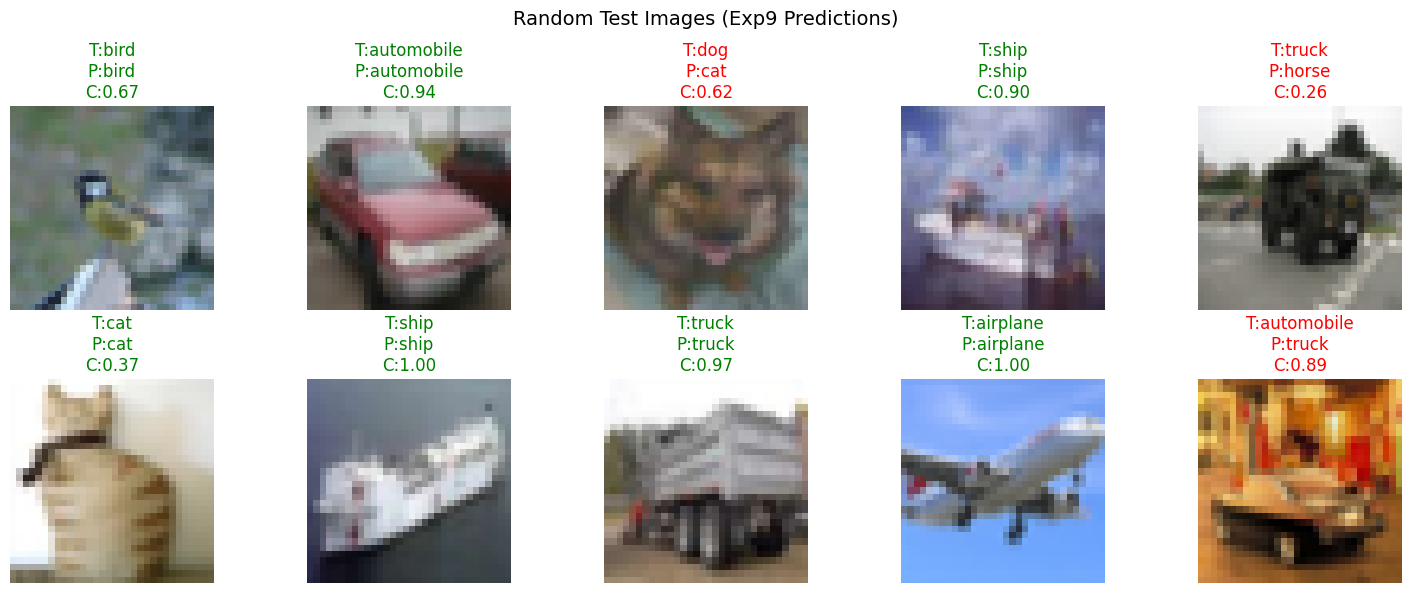

In [ ]:
np.random.seed(42)
sample_idxs = np.random.choice(len(x_test_norm), size=10, replace=False)
show_image_grid(sample_idxs, "Random Test Images (Exp9 Predictions)", n=10)


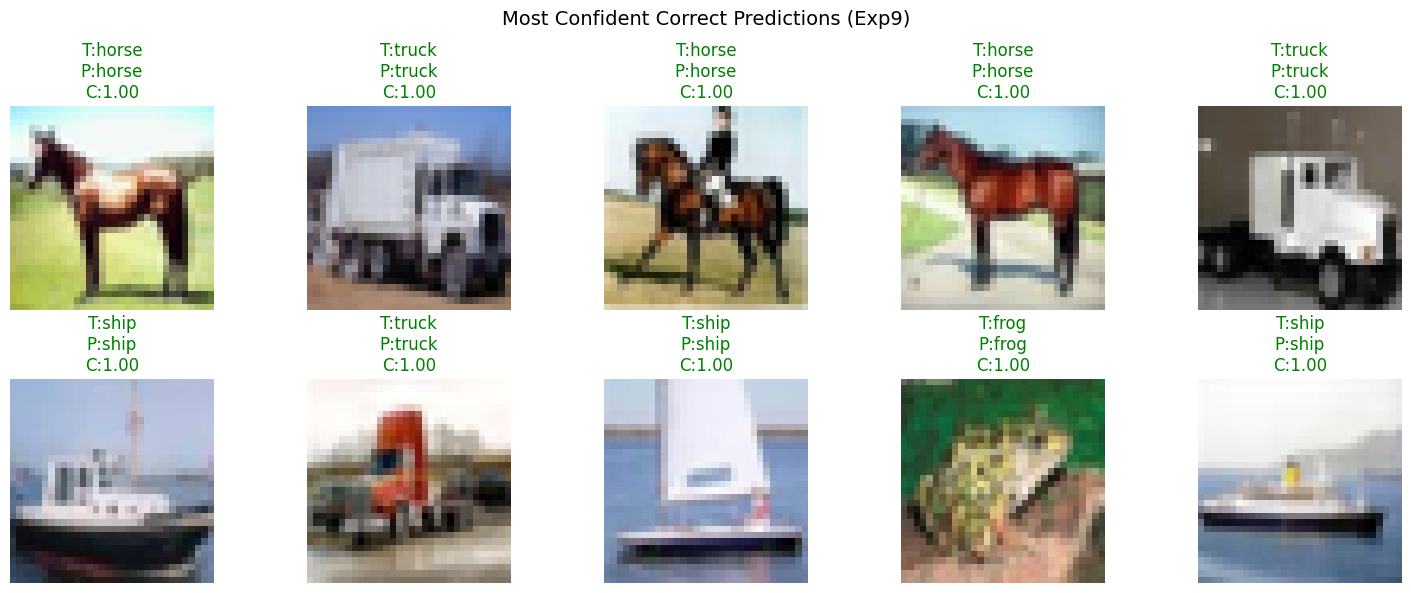

In [ ]:
top_correct = correct_idx[np.argsort(conf9[correct_idx])[::-1]]
show_image_grid(top_correct, "Most Confident Correct Predictions (Exp9)", n=10)


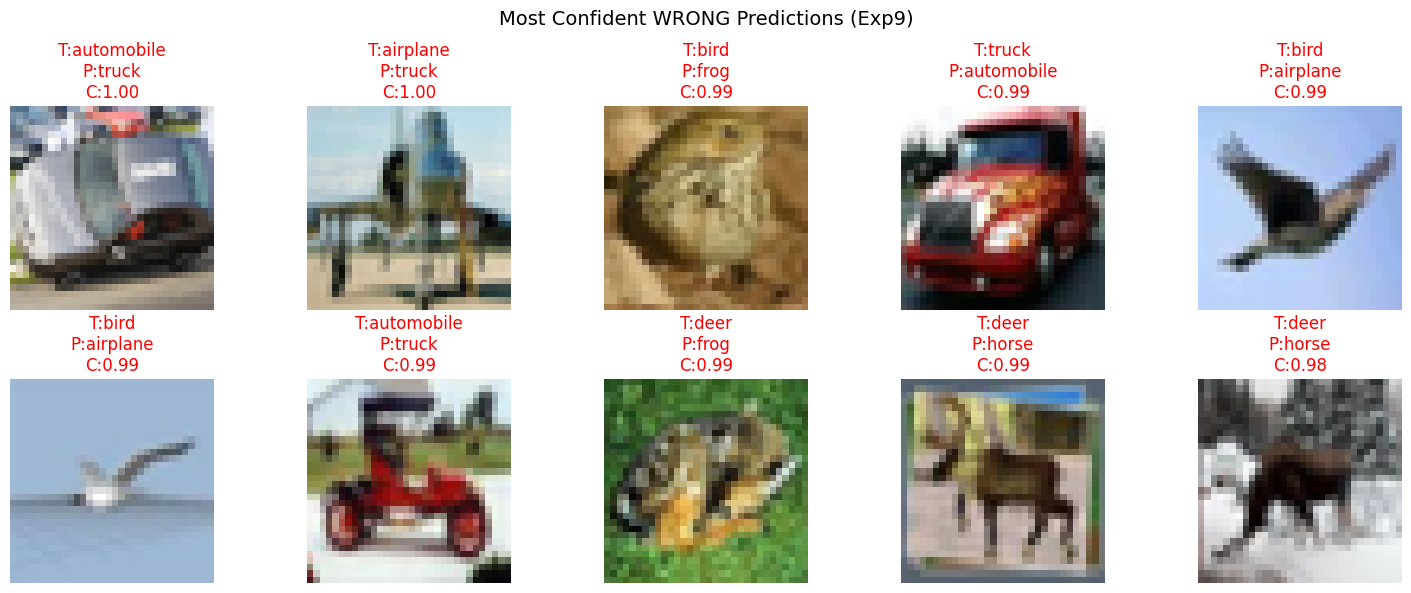

In [ ]:
top_wrong = wrong_idx[np.argsort(conf9[wrong_idx])[::-1]]
show_image_grid(top_wrong, "Most Confident WRONG Predictions (Exp9)", n=10)


# Experiment 10

In [ ]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

def plot_accuracy_loss(history, exp_name=""):
    df = pd.DataFrame(history.history)
    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(df["accuracy"], label="Train Accuracy")
    plt.plot(df["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy vs Epochs ({exp_name})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(df["loss"], label="Train Loss")
    plt.plot(df["val_loss"], label="Validation Loss")
    plt.title(f"Loss vs Epochs ({exp_name})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

def plot_confusion_matrix_labeled(y_true, y_pred, exp_name=""):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap="Blues", fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"Confusion Matrix ({exp_name})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [ ]:
K.clear_session()
exp_name10 = "Exp10_CNN_2block_strong_reg"

# Stronger regularization than Exp9
L2_LAMBDA_10 = 5e-4     # Exp9 was 1e-4
DROPOUT_10   = 0.35     # Exp9 was 0.25

cnn2_strong_reg = Sequential([
    Input(shape=(32, 32, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           kernel_regularizer=l2(L2_LAMBDA_10)),
    MaxPooling2D((2,2)),
    Dropout(DROPOUT_10),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=l2(L2_LAMBDA_10)),
    MaxPooling2D((2,2)),
    Dropout(DROPOUT_10),

    # Classifier
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(L2_LAMBDA_10)),
    Dropout(DROPOUT_10),
    Dense(10, activation='softmax')
], name=exp_name10)

cnn2_strong_reg.summary()

Model: "Exp10_CNN_2block_strong_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history10, time10, path10 = compile_train_model(
    cnn2_strong_reg, exp_name10,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    optimizer='adam',
    batch_size=64,
    epochs=200,
    patience=3,
    save_dir=base_dir
)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 126ms/step - accuracy: 0.2972 - loss: 2.0134 - val_accuracy: 0.4946 - val_loss: 1.5146
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 162ms/step - accuracy: 0.4724 - loss: 1.5521 - val_accuracy: 0.5434 - val_loss: 1.3640
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.5169 - loss: 1.4562 - val_accuracy: 0.5832 - val_loss: 1.3012
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.5456 - loss: 1.4012 - val_accuracy: 0.6174 - val_loss: 1.2483
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.5675 - loss: 1.3604 - val_accuracy: 0.6306 - val_loss: 1.2036
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 160s 153ms/step - accuracy: 0.5840 - loss: 1.3299 - val_accuracy: 0.6516 - val_loss: 1.1744
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 142ms/step - accuracy: 0.5888 - loss: 1.3105 - val_accuracy: 0.6510 - val_loss: 1.1635
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 140ms/step - accuracy: 0.600

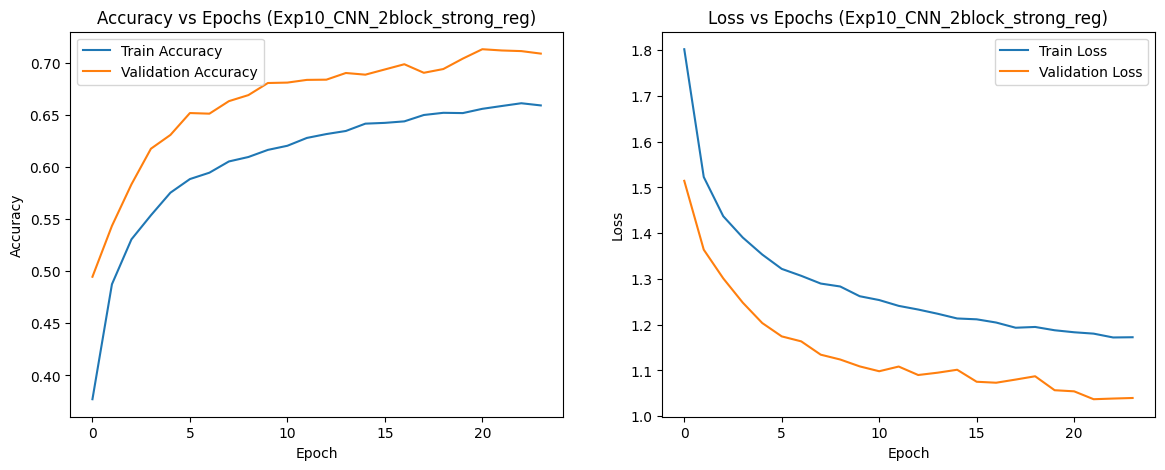

In [ ]:
plot_accuracy_loss(history10, exp_name10)

In [ ]:
best10 = load_model(path10)

train_loss10, train_acc10 = best10.evaluate(x_train_norm, y_train_split, verbose=0)
val_loss10, val_acc10     = best10.evaluate(x_valid_norm, y_valid_split, verbose=0)
test_loss10, test_acc10   = best10.evaluate(x_test_norm,  y_test,        verbose=0)

In [ ]:

print(f"Train acc: {train_acc10:.4f} | Train loss: {train_loss10:.4f}")
print(f"Val   acc: {val_acc10:.4f} | Val   loss: {val_loss10:.4f}")
print(f"Test  acc: {test_acc10:.4f} | Test  loss: {test_loss10:.4f}")
print(f"Train time (sec): {time10}")
print(f"Epochs ran: {len(history10.history['loss'])}")

Train acc: 0.7589 | Train loss: 0.9266
Val   acc: 0.7116 | Val   loss: 1.0370
Test  acc: 0.7101 | Test  loss: 1.0534
Train time (sec): 2556.86
Epochs ran: 24


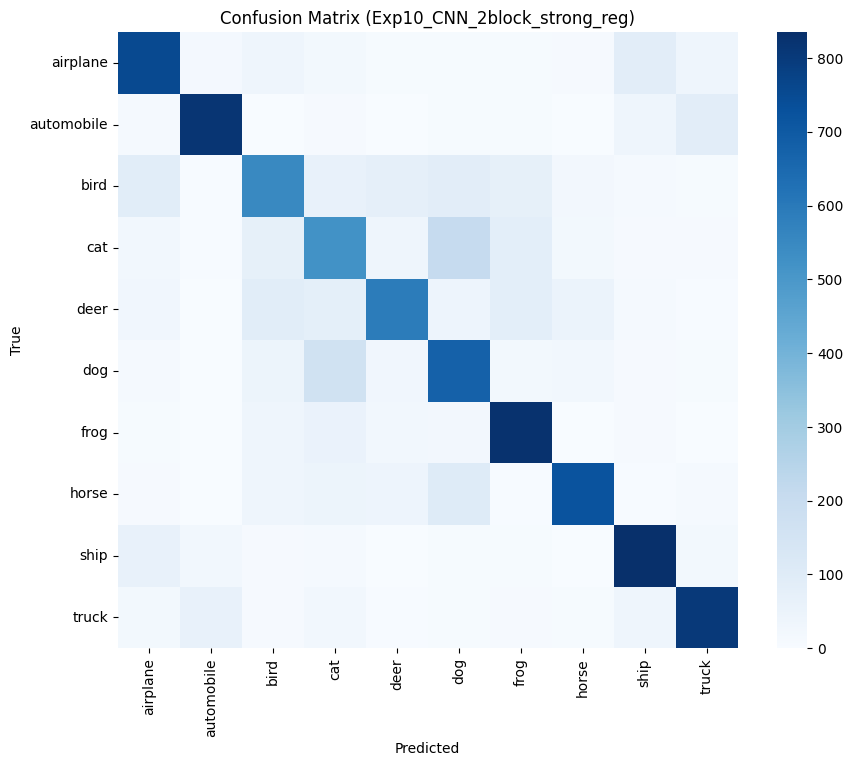

In [ ]:
y_prob10 = best10.predict(x_test_norm, verbose=0)
y_pred10 = np.argmax(y_prob10, axis=1)
y_true10 = y_test.reshape(-1)

plot_confusion_matrix_labeled(y_true10, y_pred10, exp_name10)

In [ ]:
try:
    row10 = {
        "experiment": exp_name10,
        "params": cnn2_strong_reg.count_params(),
        "train_loss": float(train_loss10),
        "train_acc": float(train_acc10),
        "val_loss": float(val_loss10),
        "val_acc": float(val_acc10),
        "test_loss": float(test_loss10),
        "test_acc": float(test_acc10),
        "train_time_sec": float(time10),
        "optimizer": "adam",
        "batch_size": 64,
        "epochs_ran": len(history10.history["loss"])
    }
    results_df = pd.concat([results_df, pd.DataFrame([row10])], ignore_index=True)
    display(results_df.tail(10))
except NameError:
    print("\n(results_df not found) Create results_df first if you want tracking.")

,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp9_CNN_2block_L2_dropout,545098,0.662891,0.827044,0.899798,0.7258,0.920680,0.7241,2099.44,adam,64,19
1,Exp10_CNN_2block_strong_reg,545098,0.926563,0.758889,1.036976,0.7116,1.053396,0.7101,2556.86,adam,64,24


In [ ]:
y_prob10 = best10.predict(x_test_norm, verbose=0)
y_pred10 = np.argmax(y_prob10, axis=1)
y_true10 = y_test.reshape(-1)
conf10   = np.max(y_prob10, axis=1)

correct_idx10 = np.where(y_pred10 == y_true10)[0]
wrong_idx10   = np.where(y_pred10 != y_true10)[0]

print("Test accuracy:", len(correct_idx10) / len(y_true10))


Test accuracy: 0.7101


In [ ]:
def show_image_grid_exp10(idxs, title, n=10):
    n = min(n, len(idxs))
    plt.figure(figsize=(15,6))

    for i, idx in enumerate(idxs[:n]):
        img = x_test_norm[idx]
        true = y_true10[idx]
        pred = y_pred10[idx]
        c = conf10[idx]

        plt.subplot(2,5,i+1)
        plt.imshow(img)
        color = "green" if pred == true else "red"
        plt.title(
            f"T:{class_names[true]}\nP:{class_names[pred]}\nC:{c:.2f}",
            color=color
        )
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


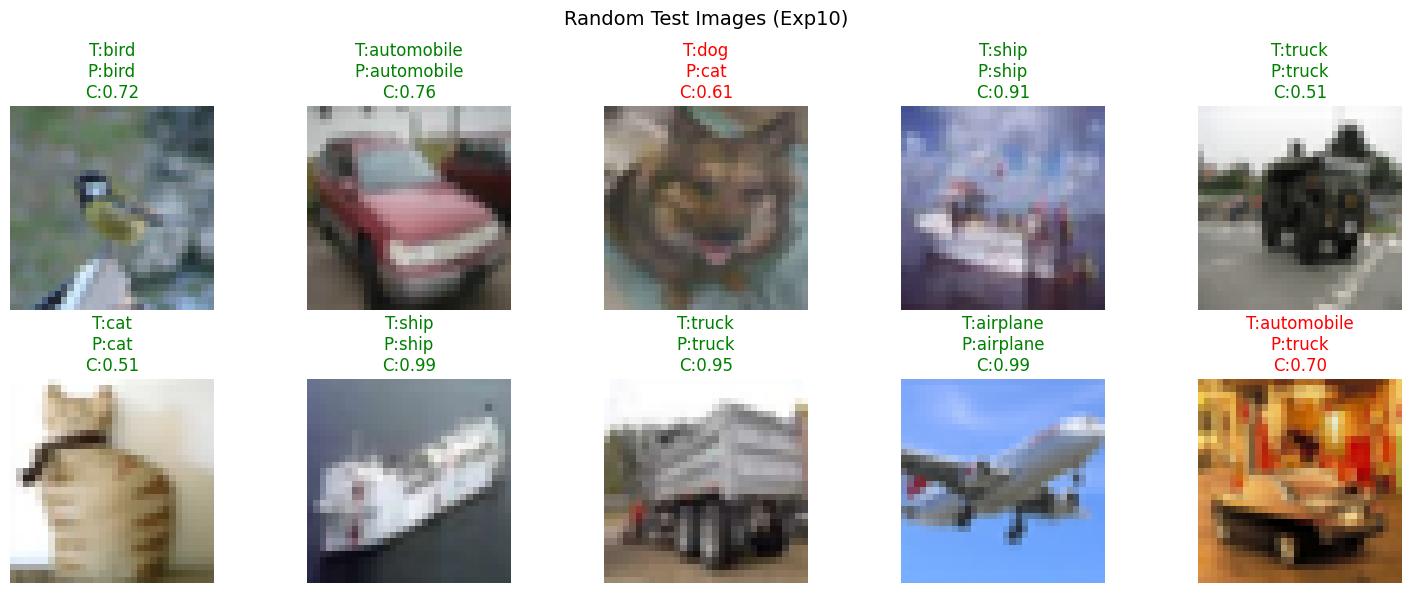

In [ ]:
np.random.seed(42)
rand_idxs = np.random.choice(len(x_test_norm), size=10, replace=False)
show_image_grid_exp10(rand_idxs, "Random Test Images (Exp10)", n=10)


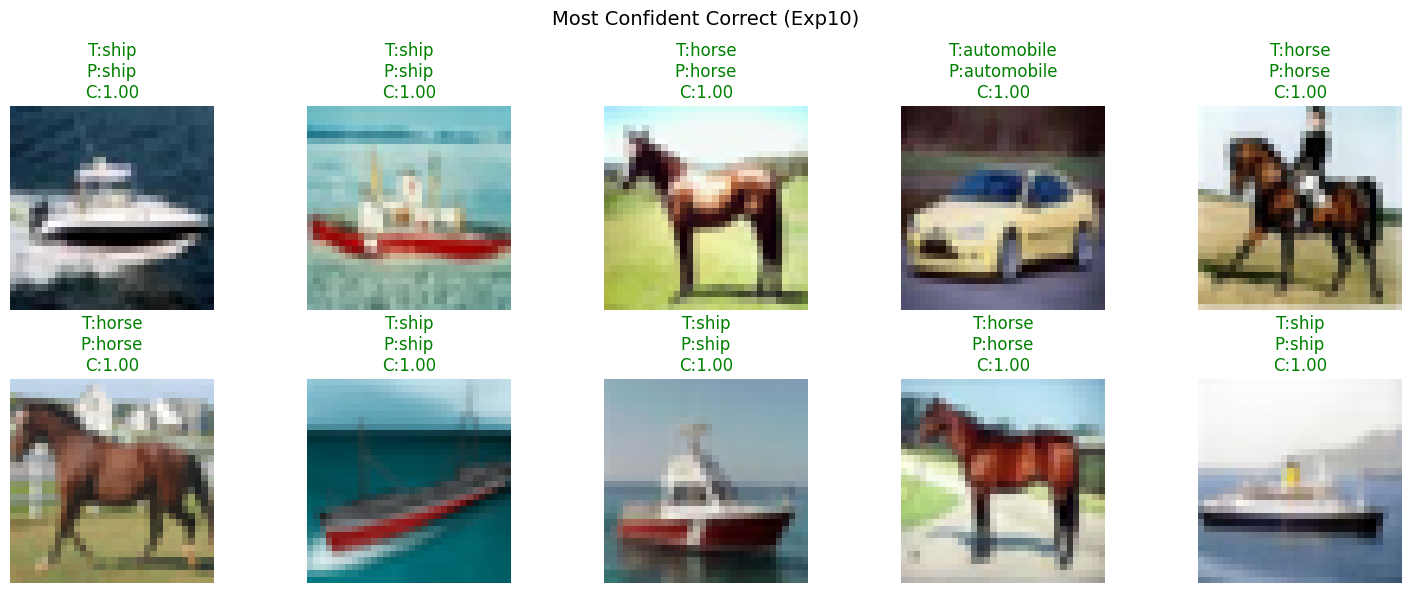

In [ ]:
top_correct10 = correct_idx10[np.argsort(conf10[correct_idx10])[::-1]]
show_image_grid_exp10(top_correct10, "Most Confident Correct (Exp10)", n=10)


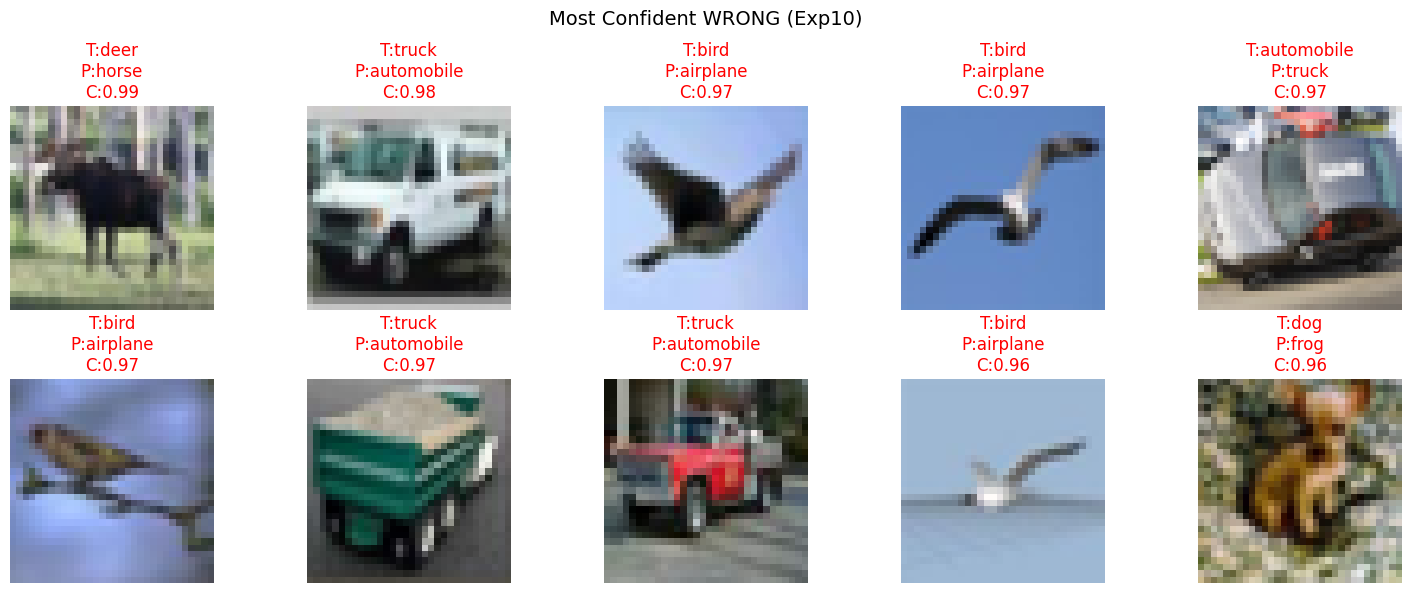

In [ ]:
top_wrong10 = wrong_idx10[np.argsort(conf10[wrong_idx10])[::-1]]
show_image_grid_exp10(top_wrong10, "Most Confident WRONG (Exp10)", n=10)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive"

for root, dirs, files in os.walk(base_path):
    for name in files:
        if name.endswith((".keras", ".h5")):
            print(os.path.join(root, name))


/content/drive/MyDrive/mnist_models/best_hidden85.keras
/content/drive/MyDrive/MSDS458_RA02_Experiments/Exp2_DNN_3hidden_no_reg.keras
/content/drive/MyDrive/MSDS458_RA02_Experiments/Exp9_CNN_2block_L2_dropout.keras
/content/drive/MyDrive/MSDS458_RA02_Experiments/Exp10_CNN_2block_strong_reg.keras
/content/drive/MyDrive/MSDS458_RA02/Exp6_DNN_2hidden_bn_dropout_l2.keras


In [ ]:
import re

# Extract experiment number (Exp1, Exp2, ..., Exp10) into a helper column
results_ordered = results_df.copy()
results_ordered["exp_num"] = results_ordered["experiment"].apply(
    lambda x: int(re.search(r"Exp(\d+)", x).group(1))
)

# Sort by experiment number
results_ordered = (
    results_ordered
    .sort_values("exp_num")
    .drop(columns="exp_num")
    .reset_index(drop=True)
)

display(results_ordered)

# Save ordered table
out_path = "/content/drive/MyDrive/MSDS458_RA02_Experiments/Result1_table.csv"
results_ordered.to_csv(out_path, index=False)
print("Saved ordered Result 1 table to:", out_path)


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp1_DNN_2hidden_no_reg,1255882,1.244229,0.559467,1.423928,0.5020,1.411031,0.5050,164.68,adam,64,17
1,Exp2_DNN_3hidden_no_reg,1738890,1.366026,0.509356,1.527360,0.4518,1.493653,0.4712,283.77,adam,64,9
2,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.50,adam,64,16
3,Exp4_CNN_3block_no_reg,356810,0.316399,0.887667,0.923465,0.7428,0.794473,0.7432,1142.61,adam,64,10
4,Exp5_DNN_2hidden_dropout,1255882,1.737181,0.373000,1.706320,0.3936,1.684457,0.4053,256.20,adam,64,16
5,Exp6_CNN_3block_dropout,356810,0.449504,0.846000,0.645920,0.7698,0.682221,0.7651,2794.48,adam,64,23
6,Exp7_CNN_3block_batchnorm,358218,0.523600,0.819400,0.780100,0.7368,1.197226,0.6707,564.95,adam,64,7
7,Exp8_CNN_3block_batchnorm_dropout,358218,0.477204,0.834933,0.637082,0.7770,0.654134,0.7735,2657.30,adam,64,15
8,Exp9_CNN_2block_L2_dropout,545098,0.662891,0.827044,0.899798,0.7258,0.920680,0.7241,2099.44,adam,64,19
9,Exp10_CNN_2block_strong_reg,545098,0.926563,0.758889,1.036976,0.7116,1.053396,0.7101,2556.86,adam,64,24


Saved ordered Result 1 table to: /content/drive/MyDrive/MSDS458_RA02_Experiments/Result1_table.csv


# Experiemnt 11 DNN 3 hidden layers + Dropout + L2 (redo of Exp2 w/ regularization)

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, BatchNormalization
from tensorflow.keras.regularizers import l2
import time
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
tf.keras.backend.clear_session()

In [ ]:

exp_name11 = "Exp11_DNN_3hidden_dropout_L2"
save_dir = "/content/drive/MyDrive/MSDS458_RA02_Experiments"
os.makedirs(save_dir, exist_ok=True)
model_path11 = f"{save_dir}/{exp_name11}.keras"

In [ ]:
dnn3_reg = Sequential([
    Input(shape=(32,32,3)),
    Flatten(),

    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(10, activation='softmax')
], name=exp_name11)

dnn3_reg.summary()

dnn3_reg.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        model_path11, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1
    )
]

start = time.time()
history11 = dnn3_reg.fit(
    x_train_norm, y_train_split,
    validation_data=(x_valid_norm, y_valid_split),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
train_time11 = time.time() - start

# ---- Evaluate (best weights already restored) ----
train_loss11, train_acc11 = dnn3_reg.evaluate(x_train_norm, y_train_split, verbose=0)
val_loss11, val_acc11     = dnn3_reg.evaluate(x_valid_norm, y_valid_split, verbose=0)
test_loss11, test_acc11   = dnn3_reg.evaluate(x_test_norm, y_test, verbose=0)

epochs_ran11 = len(history11.history["loss"])
params11 = dnn3_reg.count_params()

Model: "Exp11_DNN_3hidden_dropout_L2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1800 - loss: 2.3110
Epoch 1: val_accuracy improved from -inf to 0.30740, saving model to /content/drive/MyDrive/MSDS458_RA02_Experiments/Exp11_DNN_3hidden_dropout_L2.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.1801 - loss: 2.3106 - val_accuracy: 0.3074 - val_loss: 1.9680
Epoch 2/200
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2690 - loss: 2.0219
Epoch 2: val_accuracy improved from 0.30740 to 0.32500, saving model to /content/drive/MyDrive/MSDS458_RA02_Experiments/Exp11_DNN_3hidden_dropout_L2.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.2691 - loss: 2.0218 - val_accuracy: 0.3250 - val_loss: 1.9155
Epoch 3/200
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2881 - loss: 1.9711
Epoch 3: val_accuracy improved from 0.32500 to 0.33400, saving model to /content/drive/MyDrive/MSDS458_RA02_Experiments/Exp11_DNN_3hidden_dropout_L2.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41m

In [ ]:
train_loss11, train_acc11 = dnn3_reg.evaluate(x_train_norm, y_train_split, verbose=0)
val_loss11, val_acc11     = dnn3_reg.evaluate(x_valid_norm, y_valid_split, verbose=0)
test_loss11, test_acc11   = dnn3_reg.evaluate(x_test_norm, y_test, verbose=0)

epochs_ran11 = len(history11.history["loss"])
params11 = dnn3_reg.count_params()

print("\n=== Exp11 Summary ===")
print("Saved model to:", model_path11)
print(f"Params: {params11}")
print(f"Train: loss={train_loss11:.4f}, acc={train_acc11:.4f}")
print(f"Val:   loss={val_loss11:.4f}, acc={val_acc11:.4f}")
print(f"Test:  loss={test_loss11:.4f}, acc={test_acc11:.4f}")
print(f"Train time (sec): {train_time11:.2f}")
print(f"Epochs ran: {epochs_ran11}")

# ---- Append to your results_df (same schema you used) ----
new_row = {
    "experiment": exp_name11,
    "params": params11,
    "train_loss": float(train_loss11),
    "train_acc": float(train_acc11),
    "val_loss": float(val_loss11),
    "val_acc": float(val_acc11),
    "test_loss": float(test_loss11),
    "test_acc": float(test_acc11),
    "train_time_sec": float(train_time11),
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": epochs_ran11
}

results_df = results_df._append(new_row, ignore_index=True)

# Put in order (Exp1..Exp11) based on the number inside the experiment name
results_df["exp_num"] = results_df["experiment"].str.extract(r"Exp(\d+)").astype(int)
results_df = results_df.sort_values("exp_num").drop(columns=["exp_num"]).reset_index(drop=True)

display(results_df)

# Save updated Result1 table
out_path = f"{save_dir}/Result1_table_with_Exp11.csv"
results_df.to_csv(out_path, index=False)
print("Saved updated table to:", out_path)



=== Exp11 Summary ===
Saved model to: /content/drive/MyDrive/MSDS458_RA02_Experiments/Exp11_DNN_3hidden_dropout_L2.keras
Params: 1738890
Train: loss=1.7123, acc=0.4034
Val:   loss=1.7501, acc=0.3886
Test:  loss=1.7260, acc=0.3946
Train time (sec): 714.75
Epochs ran: 20


/tmp/ipython-input-2149250177.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = results_df._append(new_row, ignore_index=True)


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp11_DNN_3hidden_dropout_L2,1738890,1.712304,0.403356,1.750123,0.3886,1.725983,0.3946,714.75056,adam,64,20


Saved updated table to: /content/drive/MyDrive/MSDS458_RA02_Experiments/Result1_table_with_Exp11.csv


In [ ]:
import pandas as pd
import re

# --- 1) Add Exp11 row to results_df ---
exp11_row = {
    "experiment": "Exp11_DNN_3hidden_dropout_L2",
    "params": 1738890,
    "train_loss": 1.712304,
    "train_acc": 0.403356,
    "val_loss": 1.750123,
    "val_acc": 0.3886,
    "test_loss": 1.725983,
    "test_acc": 0.3946,
    "train_time_sec": 714.75056,
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": 20
}

# Prevent duplicates if you run the cell twice
results_df = results_df[results_df["experiment"] != exp11_row["experiment"]].copy()

# Append
results_df = pd.concat([results_df, pd.DataFrame([exp11_row])], ignore_index=True)

# --- 2) Order by experiment number ---
results_ordered = results_df.copy()
results_ordered["exp_num"] = results_ordered["experiment"].apply(
    lambda x: int(re.search(r"Exp(\d+)", x).group(1))
)

results_ordered = (
    results_ordered
    .sort_values("exp_num")
    .drop(columns="exp_num")
    .reset_index(drop=True)
)

display(results_ordered)

# --- 3) Save ordered table ---
out_path = "/content/drive/MyDrive/MSDS458_RA02_Experiments/Result1_table_with_Exp11.csv"
results_ordered.to_csv(out_path, index=False)
print("Saved updated table to:", out_path)


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp11_DNN_3hidden_dropout_L2,1738890,1.712304,0.403356,1.750123,0.3886,1.725983,0.3946,714.75056,adam,64,20


Saved updated table to: /content/drive/MyDrive/MSDS458_RA02_Experiments/Result1_table_with_Exp11.csv
